### Notebook roadmap

This notebook follows the full coursework pipeline in order: setup, helper functions, data loading, model definition, training, test evaluation, latent-space analysis, qualitative plots, and export.


In [40]:
!git clone https://github.com/Mobinmo83/NN-DeepLearning-Assignment.git

%cd /content/NN-DeepLearning-Assignment

import sys
sys.path.append('/content/NN-DeepLearning-Assignment')

Cloning into 'NN-DeepLearning-Assignment'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 12 (delta 3), reused 8 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 32.23 MiB | 29.54 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/NN-DeepLearning-Assignment


### 1. Environment setup and libraries

These cells mount Drive, set the working path, and import the packages used for training, evaluation, plotting, and table display.

In [41]:
import torch
import torch.nn as nn
import my_utils as mu
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

### 2. Helper functions for evaluation and analysis

This stage defines the utility functions used throughout the notebook. They handle test observations, error computation, plotting, model comparison, and latent-space analysis.

In [ ]:
# Collects the latent representation r_O for one specific test setting.
# It runs the encoder on the observed (x_o, y_o) pairs and returns the latent codes as a NumPy array.
def collect_latents(net, test_contexts, setting, device):
    net.eval()
    x_o, y_o = get_test_obs(test_contexts, setting)

    with torch.no_grad():
        x_o = x_o.to(device)
        y_o = y_o.to(device)
        r_O = net.encoder(x_o, y_o)   # [N_test, r_dim]

    return r_O.cpu().numpy()


# Computes the correlation matrix between latent dimensions.
# This helps check whether latent variables are correlated or more disentangled.
def latent_correlation_matrix(r):
    return np.corrcoef(r, rowvar=False)

# Computes simple latent-space statistics based on the norm of each latent vector.
# Returns the mean and standard deviation of latent magnitudes.
def latent_space_stats(r):
    norms = np.linalg.norm(r, axis=1)
    return {
        "latent_norm_mean": float(np.mean(norms)),
        "latent_norm_std": float(np.std(norms)),
    }

# Plots a heatmap of the latent correlation matrix.
# The heatmap shows the strength of correlation between latent dimensions.
def plot_latent_corr(corr_matrix, title="Latent Correlation Matrix"):
    r_dim = corr_matrix.shape[0]
    labels = [f"r{i}" for i in range(r_dim)]

    fig, ax = plt.subplots(figsize=(3.8, 3.2))
    im = ax.imshow(np.abs(corr_matrix), cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(r_dim))
    ax.set_yticks(range(r_dim))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

    for i in range(r_dim):
        for j in range(r_dim):
            val = abs(corr_matrix[i, j])
            text_color = "white" if val > 0.55 else "#1f1f1f"
            ax.text(j, i, f"{corr_matrix[i, j]:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=7)

    ax.set_title(title, fontsize=9, color="#1f1f1f")
    ax.set_xticks(np.arange(-0.5, r_dim, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, r_dim, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_color("#1f1f1f")
        spine.set_linewidth(0.8)

    cbar = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
    cbar.set_label("|Correlation|", fontsize=8, color="#1f1f1f")
    cbar.ax.tick_params(labelsize=7, colors="#1f1f1f")

    plt.tight_layout()
    plt.show()


# Plots one test example by comparing the true curve, predicted curve,
# and the observed input points used to condition the model.
# It also shows MAE and MSE for that single sample.
def plot_one_test_prediction(net, x_test, y_test, test_contexts, setting, sample_idx, device):
    net.eval()

    test_x_obs, test_y_obs = get_test_obs(test_contexts, setting)

    with torch.no_grad():
        x_o = test_x_obs[sample_idx].unsqueeze(0).to(device)
        y_o = test_y_obs[sample_idx].unsqueeze(0).to(device)
        x_t = x_test[sample_idx].unsqueeze(0).to(device)
        y_t = y_test[sample_idx].unsqueeze(0).to(device)

        y_hat = net(x_o, y_o, x_t)

    x_np = x_t.squeeze(0).cpu().numpy()
    y_true = y_t.squeeze(0).cpu().numpy()
    y_pred = y_hat.squeeze(0).cpu().numpy()
    x_obs = x_o.squeeze(0).cpu().numpy()
    y_obs = y_o.squeeze(0).cpu().numpy()

    mae = abs(y_pred - y_true).mean()
    mse = ((y_pred - y_true) ** 2).mean()

    plt.figure(figsize=(4.8, 3.4))
    plt.plot(x_np, y_true, label="True curve", linewidth=1.8, color="#1f4e79")
    plt.plot(x_np, y_pred, label="Predicted curve", linewidth=1.8, linestyle="--", color="#4f81bd")
    plt.scatter(x_obs, y_obs, label="Observed points", s=16, color="#1f1f1f", zorder=3)

    plt.title(f"{setting} | sample {sample_idx}\nMAE={mae:.4f}, MSE={mse:.4f}",
              fontsize=9, color="#1f1f1f")
    plt.xlabel("x", fontsize=8, color="#1f1f1f")
    plt.ylabel("y", fontsize=8, color="#1f1f1f")
    plt.xticks(fontsize=7, color="#1f1f1f")
    plt.yticks(fontsize=7, color="#1f1f1f")
    plt.legend(fontsize=7, frameon=False)
    plt.grid(alpha=0.2, color="#808080")
    plt.tight_layout()
    plt.show()


# Plots pointwise prediction errors for one test sample.
# The first subplot shows absolute error and the second shows squared error across x.
def plot_one_test_errors(net, x_test, y_test, test_contexts, setting, sample_idx, device):
    net.eval()

    test_x_obs, test_y_obs = get_test_obs(test_contexts, setting)

    with torch.no_grad():
        x_o = test_x_obs[sample_idx].unsqueeze(0).to(device)
        y_o = test_y_obs[sample_idx].unsqueeze(0).to(device)
        x_t = x_test[sample_idx].unsqueeze(0).to(device)
        y_t = y_test[sample_idx].unsqueeze(0).to(device)

        y_hat = net(x_o, y_o, x_t)

    x_np = x_t.squeeze(0).cpu().numpy()
    y_true = y_t.squeeze(0).cpu().numpy()
    y_pred = y_hat.squeeze(0).cpu().numpy()

    abs_err = abs(y_pred - y_true)
    sq_err = (y_pred - y_true) ** 2

    fig, axes = plt.subplots(2, 1, figsize=(4.8, 4.0), sharex=True)

    axes[0].plot(x_np, abs_err, linewidth=1.8, color="#4f81bd")
    axes[0].set_title(f"Absolute Error | {setting} | sample {sample_idx}", fontsize=9, color="#1f1f1f")
    axes[0].set_ylabel("|y_pred - y_true|", fontsize=8, color="#1f1f1f")
    axes[0].tick_params(axis="both", labelsize=7, colors="#1f1f1f")
    axes[0].grid(alpha=0.2, color="#808080")

    axes[1].plot(x_np, sq_err, linewidth=1.8, color="#1f4e79")
    axes[1].set_title(f"Squared Error | {setting} | sample {sample_idx}", fontsize=9, color="#1f1f1f")
    axes[1].set_xlabel("x", fontsize=8, color="#1f1f1f")
    axes[1].set_ylabel("(y_pred - y_true)$^2$", fontsize=8, color="#1f1f1f")
    axes[1].tick_params(axis="both", labelsize=7, colors="#1f1f1f")
    axes[1].grid(alpha=0.2, color="#808080")

    plt.tight_layout()
    plt.show()


# Creates bar charts of MSE and MAE for all evaluation settings.
# This gives a quick visual comparison of performance across test conditions.
def plot_results_by_setting(results):
    settings = list(results.keys())
    mses = [results[s]["mse"] for s in settings]
    maes = [results[s]["mae"] for s in settings]

    bar_color = "#1f4e79"   # dark blue
    edge_color = "#1f1f1f"  # near-black

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.8))

    axes[0].bar(settings, mses, color=bar_color, edgecolor=edge_color, linewidth=0.8)
    axes[0].set_title("MSE by test setting", fontsize=10, color="#1f1f1f")
    axes[0].set_ylabel("MSE", fontsize=9, color="#1f1f1f")
    axes[0].tick_params(axis="x", rotation=30, labelsize=8, colors="#1f1f1f")
    axes[0].tick_params(axis="y", labelsize=8, colors="#1f1f1f")
    axes[0].grid(axis="y", alpha=0.2, color="#808080")

    axes[1].bar(settings, maes, color=bar_color, edgecolor=edge_color, linewidth=0.8)
    axes[1].set_title("MAE by test setting", fontsize=10, color="#1f1f1f")
    axes[1].set_ylabel("MAE", fontsize=9, color="#1f1f1f")
    axes[1].tick_params(axis="x", rotation=30, labelsize=8, colors="#1f1f1f")
    axes[1].tick_params(axis="y", labelsize=8, colors="#1f1f1f")
    axes[1].grid(axis="y", alpha=0.2, color="#808080")

    for ax in axes:
        for spine in ax.spines.values():
            spine.set_color("#1f1f1f")
            spine.set_linewidth(0.8)

    plt.tight_layout()
    plt.show()


# Builds a full comparison table across multiple models.
# For each model, it combines test-set errors with latent-space statistics into one DataFrame row.
def build_full_model_comparison(models, x_test, y_test, test_contexts, loss_fn, device):
    """
    models: dict like {"model2": net2, "model4": net4, "model8": net8}
    returns: pandas DataFrame with one row per model
    """
    setting_order = ["10_stride1", "20_stride1", "20_stride2", "10_even", "20_even"]
    rows = []

    for model_name, net in models.items():
        # test results
        results = evaluate_all_settings(net, x_test, y_test, test_contexts, loss_fn, device)

        overall_mse = sum(results[s]["mse"] for s in setting_order) / len(setting_order)
        overall_mae = sum(results[s]["mae"] for s in setting_order) / len(setting_order)
        overall_rmse = overall_mse ** 0.5

        # latent summary across all settings together
        r = collect_all_latents(net, test_contexts, device)
        corr = latent_correlation_matrix(r)
        stats = latent_space_stats(r)

        row = {
            "Model": model_name,
            "10_stride1 (MSE/MAE)": f"{results['10_stride1']['mse']:.4f} / {results['10_stride1']['mae']:.4f}",
            "20_stride1 (MSE/MAE)": f"{results['20_stride1']['mse']:.4f} / {results['20_stride1']['mae']:.4f}",
            "20_stride2 (MSE/MAE)": f"{results['20_stride2']['mse']:.4f} / {results['20_stride2']['mae']:.4f}",
            "10_even (MSE/MAE)": f"{results['10_even']['mse']:.4f} / {results['10_even']['mae']:.4f}",
            "20_even (MSE/MAE)": f"{results['20_even']['mse']:.4f} / {results['20_even']['mae']:.4f}",
            "Overall MSE": round(overall_mse, 4),
            "Overall MAE": round(overall_mae, 4),
            "Overall RMSE": round(overall_rmse, 4),
            "latent_norm_mean": round(stats["latent_norm_mean"], 4),
            "latent_norm_std": round(stats["latent_norm_std"], 4),
            "corr(r0,r1)": round(float(corr[0, 1]), 4) if corr.shape[0] > 1 else None,
        }

        rows.append(row)

    return pd.DataFrame(rows)

# Performs an SVD/PCA-style analysis of the latent space.
# It measures how much variance each principal component explains and estimates effective rank.
def latent_svd_analysis(r):
    r_centered = r - r.mean(axis=0, keepdims=True)
    _, S, _ = np.linalg.svd(r_centered, full_matrices=False)

    explained_var = (S ** 2) / (r_centered.shape[0] - 1)
    explained_ratio = explained_var / explained_var.sum()
    cumulative_ratio = np.cumsum(explained_ratio)

    p = explained_ratio[explained_ratio > 0]
    effective_rank = float(np.exp(-(p * np.log(p)).sum()))

    summary_df = pd.DataFrame({
        "PC": [f"PC{i+1}" for i in range(len(S))],
        "Explained Variance Ratio": np.round(explained_ratio, 4),
        "Cumulative Variance Ratio": np.round(cumulative_ratio, 4),
    })

    stats = {
        "n_components_90": int(np.searchsorted(cumulative_ratio, 0.90) + 1),
        "n_components_95": int(np.searchsorted(cumulative_ratio, 0.95) + 1),
        "effective_rank": round(effective_rank, 4),
    }

    return summary_df, stats

# Runs latent SVD analysis for one model and optionally plots cumulative explained variance.
# This helps show how many effective latent dimensions are really being used.
def analyse_model_svd(net, test_contexts, device, model_name="model", plot=True):
    r = collect_all_latents(net, test_contexts, device)
    summary_df, stats = latent_svd_analysis(r)

    if plot:
        fig, ax = plt.subplots(figsize=(5.2, 3.4))
        ax.plot(
            range(1, len(summary_df) + 1),
            summary_df["Cumulative Variance Ratio"],
            marker="o",
            linewidth=1.8
        )
        ax.axhline(0.90, linestyle="--", linewidth=1, label="90%")
        ax.axhline(0.95, linestyle="--", linewidth=1, label="95%")
        ax.set_title(f"{model_name}: cumulative explained variance", fontsize=10)
        ax.set_xlabel("Principal component", fontsize=9)
        ax.set_ylabel("Cumulative variance ratio", fontsize=9)
        ax.set_xticks(range(1, len(summary_df) + 1))
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, frameon=False)
        plt.tight_layout()
        plt.show()

    return summary_df, stats

# Compares SVD/PCA summaries across several models.
# Returns a compact table showing variance captured by top PCs and effective rank.
def compare_models_svd(models, test_contexts, device, max_pcs=3):
    rows = []

    for model_name, net in models.items():
        r = collect_all_latents(net, test_contexts, device)
        summary_df, stats = latent_svd_analysis(r)

        row = {"Model": model_name}

        for i in range(min(max_pcs, len(summary_df))):
            row[f"PC{i+1} var ratio"] = round(float(summary_df.loc[i, "Explained Variance Ratio"]), 4)

        row["n_components_90"] = stats["n_components_90"]
        row["n_components_95"] = stats["n_components_95"]
        row["effective_rank"] = stats["effective_rank"]

        rows.append(row)

    return pd.DataFrame(rows)

# Converts the SVD statistics dictionary into a one-row DataFrame.
# Useful for neat display in notebooks or reports.
def svd_stats_to_df(stats):
    return pd.DataFrame([{
        "n_components_90": stats["n_components_90"],
        "n_components_95": stats["n_components_95"],
        "effective_rank": stats["effective_rank"],
    }])



# Projects all latent vectors into a 2D PCA space and plots them by test setting.
# This helps visualize whether different settings form separate clusters in latent space.
def plot_latent_pca_projection(net, test_contexts, device, model_name="model"):
    setting_names = list(test_contexts.keys())
    all_r = []
    labels = []

    for setting in setting_names:
        r = collect_latents(net, test_contexts, setting, device)
        all_r.append(r)
        labels.extend([setting] * len(r))

    r = np.concatenate(all_r, axis=0)
    labels = np.array(labels)

    r_centered = r - r.mean(axis=0, keepdims=True)
    _, _, Vt = np.linalg.svd(r_centered, full_matrices=False)
    z = r_centered @ Vt.T   # PCA coordinates

    plt.figure(figsize=(5.2, 4.0))
    for setting in setting_names:
        idx = labels == setting
        plt.scatter(z[idx, 0], z[idx, 1], s=16, alpha=0.7, label=setting)

    plt.title(f"{model_name}: latent PCA projection", fontsize=10)
    plt.xlabel("PC1", fontsize=9)
    plt.ylabel("PC2", fontsize=9)
    plt.legend(fontsize=7, frameon=False)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


# Computes and plots the latent correlation matrix for one specific setting.
# Returns the matrix as a DataFrame for easier inspection.
def analyse_latent_correlation(net, test_contexts, setting, device):
    r = collect_latents(net, test_contexts, setting, device)
    corr = latent_correlation_matrix(r)

    labels = [f"r{i}" for i in range(corr.shape[0])]
    corr_df = pd.DataFrame(
        np.round(corr, 3),
        index=labels,
        columns=labels
    )

    # print(f"\nLatent correlation matrix ({setting}):")
    # print(corr_df)

    plot_latent_corr(corr, title=f"Latent correlation matrix ({setting})")

    return corr_df



# Analyses latent spaces separately for every test setting.
# Returns:
# 1) a summary table with latent norms and pairwise correlation,
# 2) a dictionary of full correlation tables for each setting.
def analyse_all_latent_spaces(net, test_contexts, device):
    summary_rows = []
    corr_tables = {}

    for setting in test_contexts.keys():
        r = collect_latents(net, test_contexts, setting, device)
        corr = latent_correlation_matrix(r)

        labels = [f"r{i}" for i in range(corr.shape[0])]
        corr_df = pd.DataFrame(
            np.round(corr, 3),
            index=labels,
            columns=labels
        )
        corr_tables[setting] = corr_df

        row = {
            "setting": setting,
            "latent_norm_mean": latent_space_stats(r)["latent_norm_mean"],
            "latent_norm_std": latent_space_stats(r)["latent_norm_std"],
            "corr(r0,r1)": float(corr[0, 1]),
        }

        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows).set_index("setting")

    for col in summary_df.columns:
        summary_df[col] = summary_df[col].round(3)

    return summary_df, corr_tables


# Collects latent vectors from all test settings and concatenates them together.
# This gives one combined latent matrix for whole-model analysis.
def collect_all_latents(net, test_contexts, device):
    all_r = []

    for setting in test_contexts.keys():
        r = collect_latents(net, test_contexts, setting, device)   # [N_test, r_dim]
        all_r.append(r)

    return np.concatenate(all_r, axis=0)   # [all_samples_across_settings, r_dim]


# Computes a single overall latent correlation matrix for the whole model
# using latent vectors from all settings combined, then plots it.
def analyse_model_latent_correlation(net, test_contexts, device, model_name="model"):
    r = collect_all_latents(net, test_contexts, device)
    corr = latent_correlation_matrix(r)

    labels = [f"r{i}" for i in range(corr.shape[0])]
    corr_df = pd.DataFrame(
        np.round(corr, 3),
        index=labels,
        columns=labels
    )

    plot_latent_corr(
        corr,
        title=f"{model_name} latent correlation matrix (r_dim={corr.shape[0]})"
    )

    return corr_df

In [ ]:
# Computes mean absolute error (MAE) for either validation or test data.
# It is included so you can measure prediction quality in a more interpretable way than MSE.
def evaluate_mae(net, x_test, y_test=None, test_contexts=None, device=None, setting=None):
    if isinstance(net, torch.nn.Module):
        net.eval()

    metric = mu.Accumulator(2)   # sum_abs_error, num_points

    with torch.no_grad():
        # validation mode: x_test is actually val_loader
        if test_contexts is None:
            for X, y in x_test:
                X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

                B, Nx = X.shape
                n_obs = random.randint(5, 20)
                idx = torch.randperm(Nx, device=X.device)[:n_obs]

                x_o = X[:, idx]
                y_o = y[:, idx]
                x_t = X
                y_t = y

                y_hat = net(x_o, y_o, x_t)
                metric.add(torch.abs(y_hat - y_t).sum().item(), y_t.numel())

        # test mode: use one chosen test observation setting
        else:
            test_x_obs, test_y_obs = get_test_obs(test_contexts, setting)

            for i in range(test_x_obs.shape[0]):
                x_o = test_x_obs[i].unsqueeze(0).to(device, non_blocking=True)
                y_o = test_y_obs[i].unsqueeze(0).to(device, non_blocking=True)
                x_t = x_test[i].unsqueeze(0).to(device, non_blocking=True)
                y_t = y_test[i].unsqueeze(0).to(device, non_blocking=True)

                y_hat = net(x_o, y_o, x_t)
                metric.add(torch.abs(y_hat - y_t).sum().item(), y_t.numel())

    return metric[0] / metric[1]


# Evaluates the model on all provided test observation settings.
# This function is included so you can build one complete table of MSE and MAE across all test cases.
def evaluate_all_settings(net, x_test, y_test, test_contexts, loss_fn, device):
    results = {}

    for setting in test_contexts.keys():
        test_loss = evaluate_loss(
            net, x_test, y_test, test_contexts, loss_fn, device, setting
        )
        test_mae = evaluate_mae(
            net, x_test, y_test, test_contexts, device, setting
        )
        results[setting] = {"mse": test_loss, "mae": test_mae}

    return results


# Computes mean loss for either validation or test data.
# It is included to measure the model with the same loss function used during optimisation.
def evaluate_loss(net, x_test, y_test=None, test_contexts=None, loss=None, device=None, setting=None):
    if isinstance(net, torch.nn.Module):
        net.eval()

    metric = mu.Accumulator(2)   # sum_loss, num_points

    with torch.no_grad():
        # validation mode: x_test is actually val_loader
        if test_contexts is None:
            for X, y in x_test:
                X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

                B, Nx = X.shape
                n_obs = random.randint(5, 20)
                idx = torch.randperm(Nx, device=X.device)[:n_obs]

                x_o = X[:, idx]
                y_o = y[:, idx]
                x_t = X
                y_t = y

                y_hat = net(x_o, y_o, x_t)
                l = loss(y_hat, y_t)
                metric.add(float(l) * y_t.numel(), y_t.numel())

        # test mode: use one chosen test observation setting
        else:
            test_x_obs, test_y_obs = get_test_obs(test_contexts, setting)

            for i in range(test_x_obs.shape[0]):
                x_o = test_x_obs[i].unsqueeze(0).to(device, non_blocking=True)
                y_o = test_y_obs[i].unsqueeze(0).to(device, non_blocking=True)
                x_t = x_test[i].unsqueeze(0).to(device, non_blocking=True)
                y_t = y_test[i].unsqueeze(0).to(device, non_blocking=True)

                y_hat = net(x_o, y_o, x_t)
                l = loss(y_hat, y_t)
                metric.add(float(l) * y_t.numel(), y_t.numel())

    return metric[0] / metric[1]


# Runs one full training epoch over the training set.
# It is included to handle one epoch of optimisation and return both training loss and training MAE.
def train_epoch(net, train_iter, loss, optimizer, device, batch_size=256, num_outputs=10):
    if isinstance(net, torch.nn.Module):
        net.train()

    metric = mu.Accumulator(3)   # sum_loss, sum_abs_error, num_points

    for X, y in train_iter:
        X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

        # sample_context_target(X, y, min_obs=5, max_obs=20)
        B, Nx = X.shape
        n_obs = random.randint(5, 20)
        idx = torch.randperm(Nx, device=X.device)[:n_obs]

        x_o = X[:, idx]
        y_o = y[:, idx]
        x_t = X
        y_t = y


        optimizer.zero_grad()
        y_hat = net(x_o, y_o, x_t)
        l = loss(y_hat, y_t)
        l.backward()
        optimizer.step()

        with torch.no_grad():
            metric.add(
                l.item() * y_t.numel(),
                torch.abs(y_hat - y_t).sum().item(),
                y_t.numel()
            )

    return metric[0] / metric[2], metric[1] / metric[2]


## THIS TRAIN FUNCTION BEEN USED FOR HYPER PARAMETER TUNING OF MODEL USING VALIDATION SET

# def train(net, train_iter, val_iter, loss, num_epochs, optimizer, scheduler, device):
#     net = net.to(device)

#     animator = mu.Animator(
#         xlabel='epoch',
#         xlim=[1, num_epochs],
#         legend=['train loss', 'train mae', 'val loss', 'val mae']
#     )

#     logs = []

#     for epoch in range(num_epochs):
#         train_loss, train_mae = train_epoch(net, train_iter, loss, optimizer, device)

#         net.eval()
#         with torch.no_grad():
#             val_loss = evaluate_loss(net, val_iter, None, None, loss, device)
#             val_mae = evaluate_mae(net, val_iter, None, None, device)

#         scheduler.step(val_loss)

#         animator.add(epoch + 1, (train_loss, train_mae, val_loss, val_mae))

#         logs.append(
#             f"epoch {epoch+1:2d}: "
#             f"train loss {train_loss:.4f}, train mae {train_mae:.4f} | "
#             f"val loss {val_loss:.4f}, val mae {val_mae:.4f}"
#         )

#         print("\n".join(logs))

#     return train_loss, train_mae, val_loss, val_mae


# It is included as the main training loop for the final model runs and logs loss, MAE, and learning rate.
def train(net, train_iter, val_iter, loss, num_epochs, optimizer, scheduler, device):
    net = net.to(device)

    animator = mu.Animator(
        xlabel='epoch',
        xlim=[1, num_epochs],
        legend=['train loss', 'train mae']
    )

    logs = []

    for epoch in range(num_epochs):
        train_loss, train_mae = train_epoch(net, train_iter, loss, optimizer, device)

        scheduler.step(train_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        animator.add(epoch + 1, (train_loss, train_mae))

        logs.append(
            f"epoch {epoch+1:2d}: "
            f"train loss {train_loss:.4f}, train mae {train_mae:.4f}, lr {current_lr:.6g}"
        )

        print("\n".join(logs))

    return train_loss, train_mae, None, None



# Extracts the observed x and y points for one named test setting.
# It is included to make test-context loading reusable and keep evaluation code cleaner.
def get_test_obs(test_contexts, setting):
    obs = test_contexts[setting]
    test_x_obs = obs["x"].float().squeeze(-1)
    test_y_obs = obs["y"].float().squeeze(-1)
    return test_x_obs, test_y_obs

### 3. Data loading and preparation

Here the training and test data are loaded, converted to tensors, and arranged into the format required by the model.

Each function is represented on the same 100 x-values in the range [-1, 1]. The training loader is then created so batches of functions can be sampled during optimisation.

In [ ]:
# x_train[i] = the 100 x-values for function i
# y_train[i] = the 100 y-values for function i

y_all = torch.from_numpy(np.loadtxt('train_data.csv', delimiter=',')).float()

# N_all = 30000 → number of training functions
# Nx = 100 → number of sampled points per function
N_all, Nx = y_all.shape

x_all = torch.from_numpy(np.tile(np.linspace(-1, 1, Nx), (N_all, 1))).float()

# build full dataset first
full_dataset = TensorDataset(x_all, y_all)

# use ALL training data
train_dataset = full_dataset

# no validation set vlidation set only be used for hyperparamter tuning
val_dataset = None

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = None

# test data stays untouched
y_test = torch.from_numpy(np.loadtxt('test_data.csv', delimiter=',')).float()
x_test = torch.linspace(-1, 1, 100).unsqueeze(0).repeat(y_test.shape[0], 1)

# Load the context bundle
test_contexts = torch.load('test_observations.pt')


### 4. Model definition

This section implements the required two-part architecture from the coursework:

- **Encoder:** maps observed pairs $(x_o, y_o)$ into latent representations and averages them into a single context vector.
- **Decoder:** combines the context vector with target inputs $x_t$ to predict $\hat{y}_t$.

The latent size $r_{dim}$ is configurable, which allows training model2, model4, and model8 with the same architecture and only one controlled change.

In [ ]:
# Encoder MLP that maps each observed pair (x_o, y_o) to a latent representation.
# It is included to summarise the observed points into a single latent vector r_O
# that represents the underlying function.
class Encoder(nn.Module):
    def __init__(self, h_dim=128, r_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, r_dim)
        )

    # Takes the observed x and y pairs, combines them into 2D inputs,
    # maps each observed pair into a latent code, and then averages across
    # all observed points to produce one function-level representation r_O.
    def forward(self, x_o, y_o):
        xy = torch.stack([x_o, y_o], dim=-1)
        r_i = self.net(xy)
        r_O = r_i.mean(dim=1)
        return r_O


# Decoder MLP that takes the latent representation r_O together with target x values.
# It is included to predict the corresponding target outputs y_hat for the selected function.
class Decoder(nn.Module):
    def __init__(self, h_dim=128, r_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(r_dim + 1, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, 1)
        )

    # Repeats the latent vector across all target points, concatenates it with x_t,
    # and passes the combined input through the decoder to predict y values.
    def forward(self, r_O, x_t):
        B, N_target = x_t.shape
        # r_rep = r_O.unsqueeze(1).repeat(1, N_target, 1)
        r_rep = r_O.unsqueeze(1).expand(-1, N_target, -1)
        x_t = x_t.unsqueeze(-1)
        dec_in = torch.cat([r_rep, x_t], dim=-1)
        y_hat = self.net(dec_in).squeeze(-1)
        return y_hat


# Full model that combines the encoder and decoder into one end-to-end network.
# It is included so the observed data can first define the function representation
# and then that representation can be used to predict outputs at target x values.
class Model(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    # Runs the full forward pass:
    # 1) encode observed points into r_O
    # 2) decode r_O with target x values to get predictions y_hat
    def forward(self, x_o, y_o, x_t):
        r_O = self.encoder(x_o, y_o)
        y_hat = self.decoder(r_O, x_t)
        return y_hat



# Returns a weight-initialisation function for the model.
# It is included to initialise hidden ReLU layers with Kaiming initialisation
# and the final encoder/decoder output layers with Xavier initialisation.
def init_weights(r_dim):
    def _init_weights(m):
        if isinstance(m, nn.Linear):
            # final encoder layer -> Xavier
            # final decoder layer -> Xavier
            # hidden layers with ReLU -> Kaiming
            if m.out_features == r_dim or m.out_features == 1:
                nn.init.xavier_uniform_(m.weight)
            else:
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)
    return _init_weights

### 5. Training setup

The training configuration is defined here: device, loss function, weight initialisation, optimiser, and learning-rate scheduler.

The objective is mean squared error, because the task is curve regression and we want the predicted curve to stay close to the ground-truth function over all target points.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loss = nn.MSELoss()

### 6. Train **model2** ($r_{dim}=2$)

This is the smallest latent representation. It gives a compact baseline and shows how well the model can fit the family of functions with very limited latent capacity.

epoch  1: train loss 0.1644, train mae 0.2825, lr 0.002
epoch  2: train loss 0.0922, train mae 0.2200, lr 0.002
epoch  3: train loss 0.0857, train mae 0.2123, lr 0.002
epoch  4: train loss 0.1000, train mae 0.2298, lr 0.002
epoch  5: train loss 0.0965, train mae 0.2223, lr 0.002
epoch  6: train loss 0.0794, train mae 0.2021, lr 0.002
epoch  7: train loss 0.0869, train mae 0.2135, lr 0.002
epoch  8: train loss 0.0754, train mae 0.1988, lr 0.002
epoch  9: train loss 0.0759, train mae 0.1988, lr 0.002
epoch 10: train loss 0.0743, train mae 0.1957, lr 0.002
epoch 11: train loss 0.0720, train mae 0.1927, lr 0.002
epoch 12: train loss 0.0681, train mae 0.1883, lr 0.002
epoch 13: train loss 0.0739, train mae 0.1957, lr 0.002
epoch 14: train loss 0.0654, train mae 0.1852, lr 0.002
epoch 15: train loss 0.0663, train mae 0.1860, lr 0.002
epoch 16: train loss 0.0704, train mae 0.1940, lr 0.002
epoch 17: train loss 0.0737, train mae 0.1942, lr 0.002
epoch 18: train loss 0.0663, train mae 0.1840, l

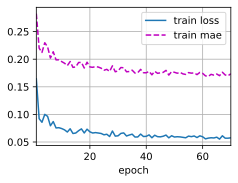

In [ ]:

print(f"Latent Dimension 2 training:")

encoder2 = Encoder(h_dim=128, r_dim=2)
decoder2 = Decoder(h_dim=128, r_dim=2)
net2 = Model(encoder2, decoder2)

net2.apply(init_weights(r_dim=2))

optimizer = torch.optim.AdamW(net2.parameters(), lr=0.002, weight_decay=5e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.8,
    patience=8,
    threshold=5e-4,
    threshold_mode="abs",
    cooldown=4,
    min_lr=1e-6
)

train_loss, train_mae, val_loss, val_mae = train(
    net=net2,
    train_iter=train_loader,
    val_iter=val_loader,
    loss=loss,
    num_epochs=70,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device
)



### 7. Train **model4** ($r_{dim}=4$)

Only the latent dimension changes here. Keeping the rest of the setup fixed makes the comparison fair and lets us measure the effect of extra latent capacity directly.

epoch  1: train loss 0.1490, train mae 0.2623, lr 0.002
epoch  2: train loss 0.0793, train mae 0.2039, lr 0.002
epoch  3: train loss 0.0820, train mae 0.2069, lr 0.002
epoch  4: train loss 0.0722, train mae 0.1929, lr 0.002
epoch  5: train loss 0.0622, train mae 0.1782, lr 0.002
epoch  6: train loss 0.0674, train mae 0.1870, lr 0.002
epoch  7: train loss 0.0570, train mae 0.1724, lr 0.002
epoch  8: train loss 0.0630, train mae 0.1796, lr 0.002
epoch  9: train loss 0.0588, train mae 0.1719, lr 0.002
epoch 10: train loss 0.0576, train mae 0.1708, lr 0.002
epoch 11: train loss 0.0527, train mae 0.1648, lr 0.002
epoch 12: train loss 0.0532, train mae 0.1633, lr 0.002
epoch 13: train loss 0.0520, train mae 0.1633, lr 0.002
epoch 14: train loss 0.0545, train mae 0.1629, lr 0.002
epoch 15: train loss 0.0503, train mae 0.1593, lr 0.002
epoch 16: train loss 0.0483, train mae 0.1552, lr 0.002
epoch 17: train loss 0.0467, train mae 0.1533, lr 0.002
epoch 18: train loss 0.0471, train mae 0.1538, l

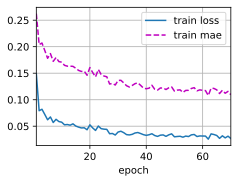

In [ ]:
print(f"Latent Dimension 4 training:")

encoder4 = Encoder(h_dim=128, r_dim=4)
decoder4 = Decoder(h_dim=128, r_dim=4)
net4 = Model(encoder4, decoder4)


net4.apply(init_weights(r_dim=4))


optimizer = torch.optim.AdamW(net4.parameters(), lr=0.002, weight_decay=5e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.8,
    patience=8,
    threshold=5e-4,
    threshold_mode="abs",
    cooldown=4,
    min_lr=1e-6
)

train_loss, train_mae, val_loss, val_mae = train(
    net=net4,
    train_iter=train_loader,
    val_iter=val_loader,
    loss=loss,
    num_epochs=70,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device
)



### 8. Train **model8** ($r_{dim}=8$)

This is the largest latent representation tested in the coursework. It allows the encoder to store richer information about the observed points before the decoder reconstructs the full curve.

epoch  1: train loss 0.1129, train mae 0.2385, lr 0.002
epoch  2: train loss 0.0888, train mae 0.2140, lr 0.002
epoch  3: train loss 0.0732, train mae 0.1894, lr 0.002
epoch  4: train loss 0.0609, train mae 0.1760, lr 0.002
epoch  5: train loss 0.0534, train mae 0.1631, lr 0.002
epoch  6: train loss 0.0544, train mae 0.1630, lr 0.002
epoch  7: train loss 0.0397, train mae 0.1365, lr 0.002
epoch  8: train loss 0.0465, train mae 0.1470, lr 0.002
epoch  9: train loss 0.0359, train mae 0.1298, lr 0.002
epoch 10: train loss 0.0352, train mae 0.1264, lr 0.002
epoch 11: train loss 0.0414, train mae 0.1377, lr 0.002
epoch 12: train loss 0.0349, train mae 0.1252, lr 0.002
epoch 13: train loss 0.0321, train mae 0.1180, lr 0.002
epoch 14: train loss 0.0329, train mae 0.1212, lr 0.002
epoch 15: train loss 0.0309, train mae 0.1201, lr 0.002
epoch 16: train loss 0.0293, train mae 0.1155, lr 0.002
epoch 17: train loss 0.0277, train mae 0.1119, lr 0.002
epoch 18: train loss 0.0312, train mae 0.1202, l

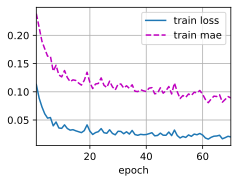

In [ ]:

print(f"Latent Dimension 8 training:")

encoder8 = Encoder(h_dim=128, r_dim=8)
decoder8 = Decoder(h_dim=128, r_dim=8)
net8 = Model(encoder8, decoder8)



net8.apply(init_weights(r_dim=8))


optimizer = torch.optim.AdamW(net8.parameters(), lr=0.002, weight_decay=5e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.8,
    patience=8,
    threshold=5e-4,
    threshold_mode="abs",
    cooldown=4,
    min_lr=1e-6
)

train_loss, train_mae, val_loss, val_mae = train(
    net=net8,
    train_iter=train_loader,
    val_iter=val_loader,
    loss=loss,
    num_epochs=70,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device
)



### 9. Test evaluation

all modelsare now evaluated on the provided test functions using the official observation settings from `test_observations.pt`.

For each setting, the notebook reports both **MSE** and **MAE**, then computes the overall average error and RMSE.

#### Test evaluation for **model2**

In [ ]:
print(f"Latent Dimension 2 test results:")

results2 = evaluate_all_settings(net2, x_test, y_test, test_contexts, loss, device)

for setting, vals in results2.items():
    print(f"{setting}: mse={vals['mse']:.4f}, mae={vals['mae']:.4f}")

overall_mse = sum(v["mse"] for v in results2.values()) / len(results2)
overall_mae = sum(v["mae"] for v in results2.values()) / len(results2)
overall_rmse = overall_mse ** 0.5

print(f"\nOverall average: mse={overall_mse:.4f}, mae={overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")

Latent Dimension 2 test results:
10_stride1: mse=0.3205, mae=0.4272
20_stride1: mse=0.2864, mae=0.3970
20_stride2: mse=0.2208, mae=0.3331
10_even: mse=0.0392, mae=0.1522
20_even: mse=0.0388, mae=0.1492

Overall average: mse=0.1811, mae=0.2917
Overall RMSE: 0.4256


#### Test evaluation for **model4**

This repeats the same evaluation protocol for `model4`, so the comparison stays consistent across all three models.

In [ ]:
print(f"Latent Dimension 4 test results :")

results4 = evaluate_all_settings(net4, x_test, y_test, test_contexts, loss, device)

for setting, vals in results4.items():
    print(f"{setting}: mse={vals['mse']:.4f}, mae={vals['mae']:.4f}")

overall_mse = sum(v["mse"] for v in results4.values()) / len(results4)
overall_mae = sum(v["mae"] for v in results4.values()) / len(results4)
overall_rmse = overall_mse ** 0.5

print(f"\nOverall average: mse={overall_mse:.4f}, mae={overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")

Latent Dimension 4 test results :
10_stride1: mse=0.3360, mae=0.4234
20_stride1: mse=0.2887, mae=0.3789
20_stride2: mse=0.1910, mae=0.2822
10_even: mse=0.0110, mae=0.0813
20_even: mse=0.0104, mae=0.0775

Overall average: mse=0.1674, mae=0.2487
Overall RMSE: 0.4092


#### Test evaluation for **model8**

This repeats the same test procedure for `model8`. At this point we have the full set of task-required results for all three latent sizes.

In [ ]:
print(f"Latent Dimension 8 test results :")

results8 = evaluate_all_settings(net8, x_test, y_test, test_contexts, loss, device)

for setting, vals in results8.items():
    print(f"{setting}: mse={vals['mse']:.4f}, mae={vals['mae']:.4f}")

overall_mse = sum(v["mse"] for v in results8.values()) / len(results8)
overall_mae = sum(v["mae"] for v in results8.values()) / len(results8)
overall_rmse = overall_mse ** 0.5

print(f"\nOverall average: mse={overall_mse:.4f}, mae={overall_mae:.4f}")
print(f"Overall RMSE: {overall_rmse:.4f}")

Latent Dimension 8 test results :
10_stride1: mse=0.3205, mae=0.4199
20_stride1: mse=0.2899, mae=0.3838
20_stride2: mse=0.1956, mae=0.2598
10_even: mse=0.0061, mae=0.0607
20_even: mse=0.0057, mae=0.0572

Overall average: mse=0.1636, mae=0.2363
Overall RMSE: 0.4044


### 10. Comparison table

This table brings together all test settings and the overall averages in one place. It is the main summary used to compare `model2`, `model4`, and `model8` side by side for Task 3 and Task 4.

In [ ]:
models = {
    "model2": net2,
    "model4": net4,
    "model8": net8,
}

comparison_df = build_full_model_comparison(
    models, x_test, y_test, test_contexts, loss, device
)

display(comparison_df)


,Model,10_stride1 (MSE/MAE),20_stride1 (MSE/MAE),20_stride2 (MSE/MAE),10_even (MSE/MAE),20_even (MSE/MAE),Overall MSE,Overall MAE,Overall RMSE,latent_norm_mean,latent_norm_std,"corr(r0,r1)"
0,model2,0.3205 / 0.4272,0.2864 / 0.3970,0.2208 / 0.3331,0.0392 / 0.1522,0.0388 / 0.1492,0.1811,0.2917,0.4256,0.9976,1.9217,0.8567
1,model4,0.3360 / 0.4234,0.2887 / 0.3789,0.1910 / 0.2822,0.0110 / 0.0813,0.0104 / 0.0775,0.1674,0.2487,0.4092,1.6903,1.4011,0.6037
2,model8,0.3205 / 0.4199,0.2899 / 0.3838,0.1956 / 0.2598,0.0061 / 0.0607,0.0057 / 0.0572,0.1636,0.2363,0.4044,3.8337,1.6510,-0.7500


 **Model 2 evaluation bar chart**

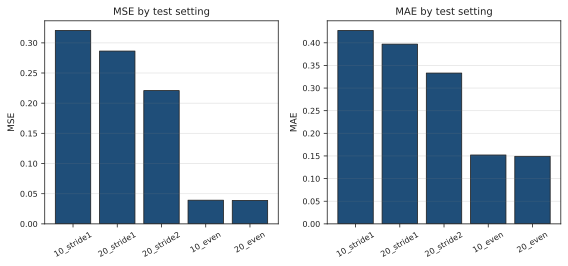

In [ ]:
results2 = evaluate_all_settings(net2, x_test, y_test, test_contexts, loss, device)
plot_results_by_setting(results2)

 **Model 4 evaluation bar chart**

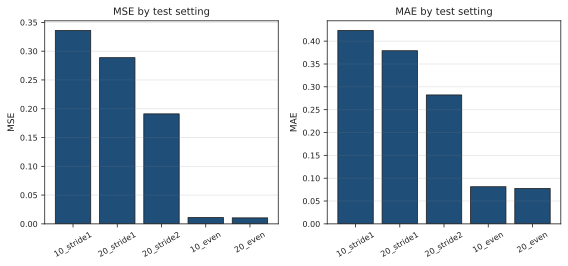

In [ ]:
results4 = evaluate_all_settings(net4, x_test, y_test, test_contexts, loss, device)
plot_results_by_setting(results4)

 **Model 8 evaluation bar chart**

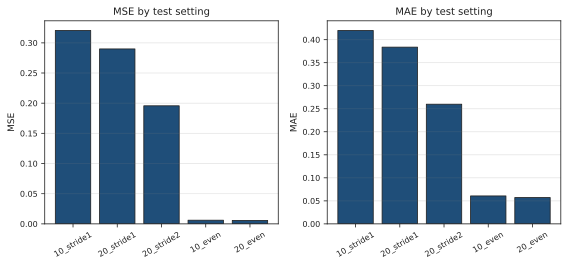

In [ ]:
results8 = evaluate_all_settings(net8, x_test, y_test, test_contexts, loss, device)
plot_results_by_setting(results8)

### 11. Global latent correlation analysis

This section measures the correlations between latent dimensions after collecting representations across all test settings.

Lower redundancy and more balanced use of dimensions suggest better disentangling, which is directly relevant to Task 5.

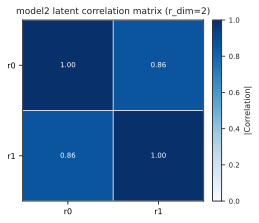

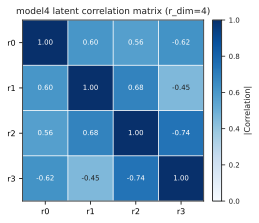

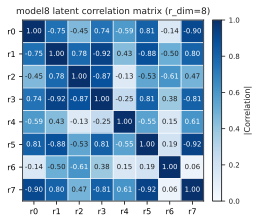

In [ ]:
corr_df2 = analyse_model_latent_correlation(net2, test_contexts, device, model_name="model2")


corr_df4 = analyse_model_latent_correlation(net4, test_contexts, device, model_name="model4")


corr_df8 = analyse_model_latent_correlation(net8, test_contexts, device, model_name="model8")


### 12. Per-setting latent correlation tables

The following outputs break the latent analysis down by observation setting. This helps check whether the same latent behaviour is stable across easy and difficult conditioning patterns.

In [ ]:
print(f"Latent Dimension 2 Summery:")
print('\n')
summary_df2, corr_tables2 = analyse_all_latent_spaces(net2, test_contexts, device)

print(summary_df2)
print('\n')
print('\n')

print(f"Latent correlation matrix (r_dim = 2):")
print(corr_df2)

print('\n')

for setting in corr_tables2:
    print(f"Latent correlation matrix ({setting}):")
    print(corr_tables2[setting])
    print()



Latent Dimension 2 Summery:


            latent_norm_mean  latent_norm_std  corr(r0,r1)
setting                                                   
10_stride1             1.307            2.889        0.995
20_stride1             1.196            2.351        0.993
20_stride2             0.944            1.580        0.987
10_even                0.792            1.005       -0.075
20_even                0.749            0.918       -0.050




Latent correlation matrix (r_dim = 2):
       r0     r1
r0  1.000  0.857
r1  0.857  1.000


Latent correlation matrix (10_stride1):
       r0     r1
r0  1.000  0.995
r1  0.995  1.000

Latent correlation matrix (20_stride1):
       r0     r1
r0  1.000  0.993
r1  0.993  1.000

Latent correlation matrix (20_stride2):
       r0     r1
r0  1.000  0.987
r1  0.987  1.000

Latent correlation matrix (10_even):
       r0     r1
r0  1.000 -0.075
r1 -0.075  1.000

Latent correlation matrix (20_even):
      r0    r1
r0  1.00 -0.05
r1 -0.05  1.00



In [ ]:
print(f"Latent Dimension 4 Summery :")
print('\n')


summary_df4, corr_tables4 = analyse_all_latent_spaces(net4, test_contexts, device)

print(summary_df4)
print('\n')
print('\n')

print(f"Latent correlation matrix (r_dim = 4):")
print(corr_df4)

print('\n')

for setting in corr_tables4:
    print(f"Latent correlation matrix ({setting}):")
    print(corr_tables4[setting])
    print()

Latent Dimension 4 Summery :


            latent_norm_mean  latent_norm_std  corr(r0,r1)
setting                                                   
10_stride1             2.492            2.019        0.722
20_stride1             2.214            1.576        0.731
20_stride2             1.617            0.918        0.196
10_even                1.091            0.615        0.681
20_even                1.037            0.573        0.638




Latent correlation matrix (r_dim = 4):
       r0     r1     r2     r3
r0  1.000  0.604  0.564 -0.618
r1  0.604  1.000  0.678 -0.452
r2  0.564  0.678  1.000 -0.740
r3 -0.618 -0.452 -0.740  1.000


Latent correlation matrix (10_stride1):
       r0     r1     r2     r3
r0  1.000  0.722  0.857 -0.972
r1  0.722  1.000  0.965 -0.733
r2  0.857  0.965  1.000 -0.830
r3 -0.972 -0.733 -0.830  1.000

Latent correlation matrix (20_stride1):
       r0     r1     r2     r3
r0  1.000  0.731  0.879 -0.974
r1  0.731  1.000  0.956 -0.721
r2  0.879  0.956  1.000 -0.

In [ ]:

print(f"Latent Dimension 8 Summery :")
print('\n')


summary_df8, corr_tables8 = analyse_all_latent_spaces(net8, test_contexts, device)

print(summary_df8)
print('\n')
print('\n')

print(f"Latent correlation matrix (r_dim = 8):")
print(corr_df8)

print('\n')

for setting in corr_tables4:
    print(f"Latent correlation matrix ({setting}):")
    print(corr_tables8[setting])
    print()

Latent Dimension 8 Summery :


            latent_norm_mean  latent_norm_std  corr(r0,r1)
setting                                                   
10_stride1             6.097            0.726       -0.981
20_stride1             5.127            0.648       -0.983
20_stride2             3.572            0.511       -0.982
10_even                2.254            0.248       -0.067
20_even                2.119            0.242       -0.179




Latent correlation matrix (r_dim = 8):
       r0     r1     r2     r3     r4     r5     r6     r7
r0  1.000 -0.750 -0.451  0.745 -0.588  0.810 -0.143 -0.905
r1 -0.750  1.000  0.785 -0.925  0.435 -0.877 -0.498  0.802
r2 -0.451  0.785  1.000 -0.872 -0.126 -0.534 -0.607  0.474
r3  0.745 -0.925 -0.872  1.000 -0.254  0.812  0.376 -0.809
r4 -0.588  0.435 -0.126 -0.254  1.000 -0.551  0.151  0.609
r5  0.810 -0.877 -0.534  0.812 -0.551  1.000  0.193 -0.924
r6 -0.143 -0.498 -0.607  0.376  0.151  0.193  1.000  0.057
r7 -0.905  0.802  0.474 -0.809  0.609 -0.

### 13. Latent-space rank and variance analysis

These cells apply an SVD/PCA analysis to the latent representations.

The aim is to see how many effective directions are being used by each model, which helps interpret how much independent structure is captured inside the latent space.

,Model,PC1 var ratio,PC2 var ratio,n_components_90,n_components_95,effective_rank,PC3 var ratio
0,model2,0.9285,0.0715,1,2,1.2937,NaN
1,model4,0.8281,0.0853,2,3,1.8720,0.0646
2,model8,0.7163,0.2074,2,3,2.3474,0.0447


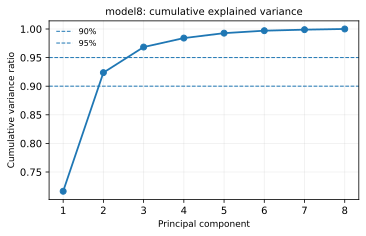

,PC,Explained Variance Ratio,Cumulative Variance Ratio
0,PC1,0.7163,0.7163
1,PC2,0.2074,0.9237
2,PC3,0.0447,0.9684
3,PC4,0.0158,0.9841
4,PC5,0.0085,0.9927
5,PC6,0.0043,0.9970
6,PC7,0.0018,0.9988
7,PC8,0.0012,1.0000


,n_components_90,n_components_95,effective_rank
0,2,3,2.3474


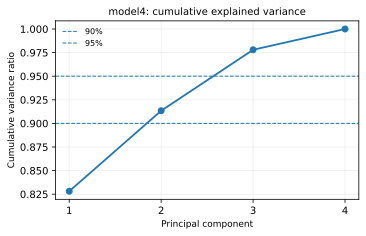

,PC,Explained Variance Ratio,Cumulative Variance Ratio
0,PC1,0.8281,0.8281
1,PC2,0.0853,0.9134
2,PC3,0.0646,0.9780
3,PC4,0.0220,1.0000


,n_components_90,n_components_95,effective_rank
0,2,3,1.872


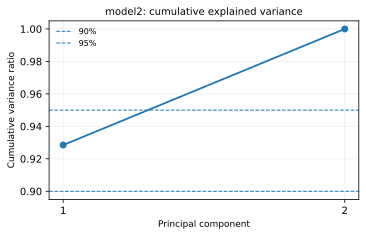

,PC,Explained Variance Ratio,Cumulative Variance Ratio
0,PC1,0.9285,0.9285
1,PC2,0.0715,1.0000


,n_components_90,n_components_95,effective_rank
0,1,2,1.2937


In [ ]:
models = {
    "model2": net2,
    "model4": net4,
    "model8": net8,
}

svd_compare_df = compare_models_svd(models, test_contexts, device, max_pcs=3)
display(svd_compare_df)

svd8_df, svd8_stats = analyse_model_svd(net8, test_contexts, device, model_name="model8", plot=True)
display(svd8_df)

svd8_stats_df = svd_stats_to_df(svd8_stats)
display(svd8_stats_df)



svd4_df, svd4_stats = analyse_model_svd(net4, test_contexts, device, model_name="model4", plot=True)
display(svd4_df)

svd4_stats_df = svd_stats_to_df(svd4_stats)
display(svd4_stats_df)




svd2_df, svd2_stats = analyse_model_svd(net2, test_contexts, device, model_name="model2", plot=True)
display(svd2_df)

svd2_stats_df = svd_stats_to_df(svd2_stats)
display(svd2_stats_df)




### 14. Qualitative examples and error curves

The remaining cells visualise individual predictions, absolute-error curves, squared-error curves, and per-setting latent correlations.

These plots are useful for interpreting *how* each model behaves, not just *how much* error it produces.

#### Qualitative examples for **model2**

These examples show where the smallest latent space works well and where it struggles, especially under harder sparse or clustered observation settings.

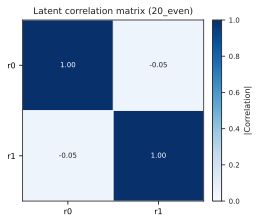

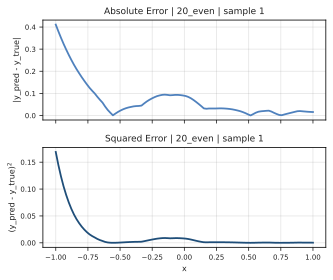

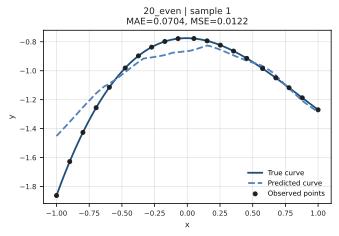

In [ ]:
corr_df = analyse_latent_correlation(net2, test_contexts, "20_even", device)
plot_one_test_errors(net2, x_test, y_test, test_contexts, "20_even", 1, device)
plot_one_test_prediction(net2, x_test, y_test, test_contexts, "20_even", 1, device)



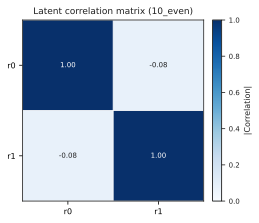

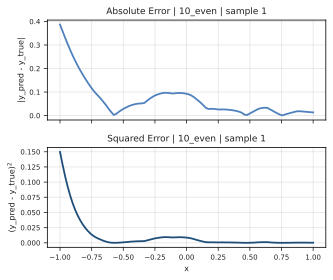

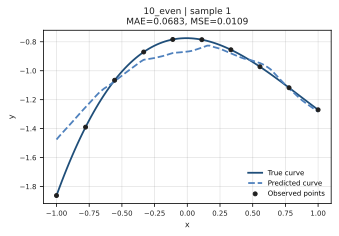

In [ ]:
corr_df = analyse_latent_correlation(net2, test_contexts, "10_even", device)

plot_one_test_errors(net2, x_test, y_test, test_contexts, "10_even", 1, device)
plot_one_test_prediction(net2, x_test, y_test, test_contexts, "10_even", 1, device)



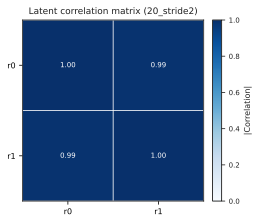

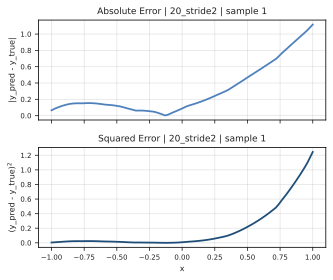

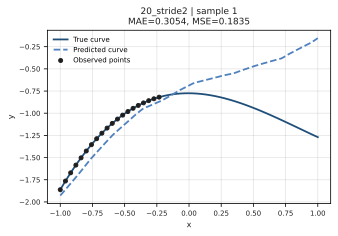

In [ ]:
corr_df = analyse_latent_correlation(net2, test_contexts, "20_stride2", device)

plot_one_test_errors(net2, x_test, y_test, test_contexts, "20_stride2", 1, device)
plot_one_test_prediction(net2, x_test, y_test, test_contexts, "20_stride2", 1, device)



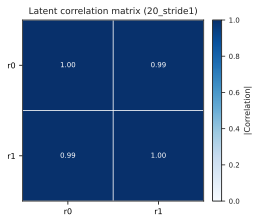

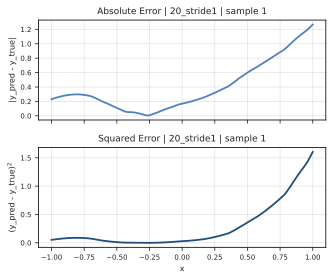

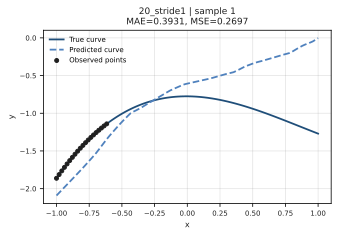

In [ ]:
corr_df = analyse_latent_correlation(net2, test_contexts, "20_stride1", device)

plot_one_test_errors(net2, x_test, y_test, test_contexts, "20_stride1", 1, device)
plot_one_test_prediction(net2, x_test, y_test, test_contexts, "20_stride1", 1, device)


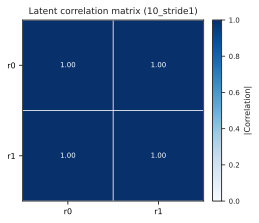

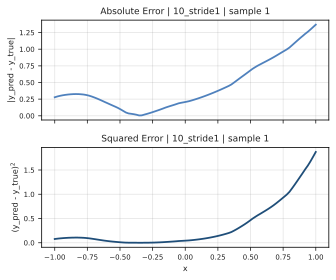

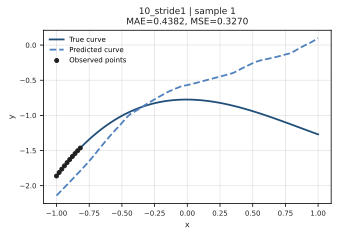

In [ ]:
corr_df = analyse_latent_correlation(net2, test_contexts, "10_stride1", device)

plot_one_test_errors(net2, x_test, y_test, test_contexts, "10_stride1", 1, device)
plot_one_test_prediction(net2, x_test, y_test, test_contexts, "10_stride1", 1, device)


#### Qualitative examples for **model4**

These plots show how the medium-sized latent space changes the shape of the prediction and the distribution of errors across the input range.

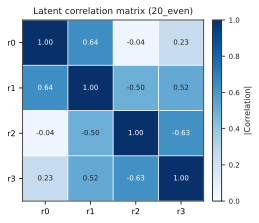

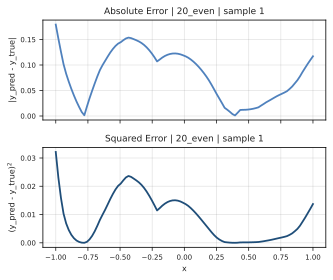

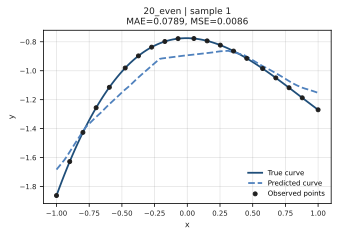

In [ ]:
corr_df = analyse_latent_correlation(net4, test_contexts, "20_even", device)
plot_one_test_errors(net4, x_test, y_test, test_contexts, "20_even", 1, device)
plot_one_test_prediction(net4, x_test, y_test, test_contexts, "20_even", 1, device)



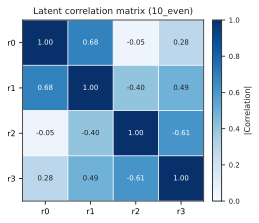

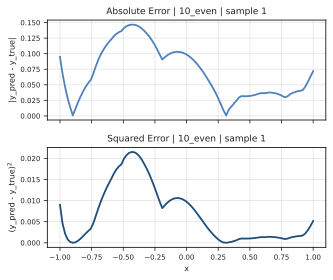

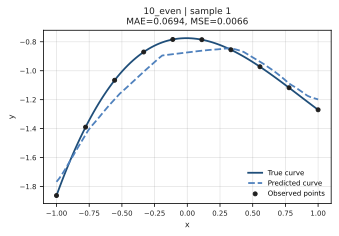

In [ ]:
corr_df = analyse_latent_correlation(net4, test_contexts, "10_even", device)

plot_one_test_errors(net4, x_test, y_test, test_contexts, "10_even", 1, device)
plot_one_test_prediction(net4, x_test, y_test, test_contexts, "10_even", 1, device)



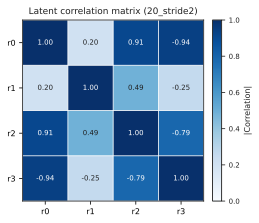

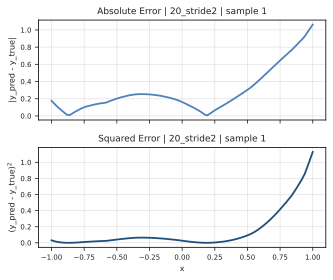

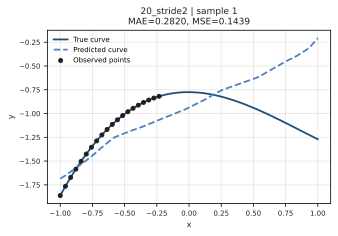

In [ ]:
corr_df = analyse_latent_correlation(net4, test_contexts, "20_stride2", device)

plot_one_test_errors(net4, x_test, y_test, test_contexts, "20_stride2", 1, device)
plot_one_test_prediction(net4, x_test, y_test, test_contexts, "20_stride2", 1, device)



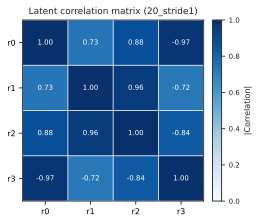

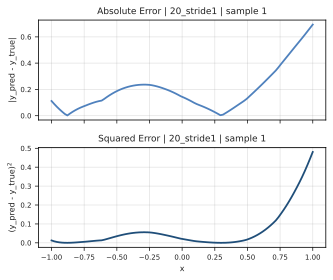

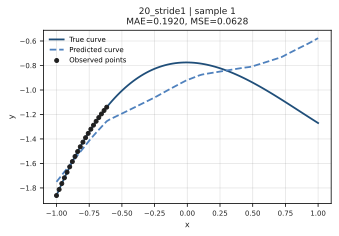

In [ ]:
corr_df = analyse_latent_correlation(net4, test_contexts, "20_stride1", device)

plot_one_test_errors(net4, x_test, y_test, test_contexts, "20_stride1", 1, device)
plot_one_test_prediction(net4, x_test, y_test, test_contexts, "20_stride1", 1, device)


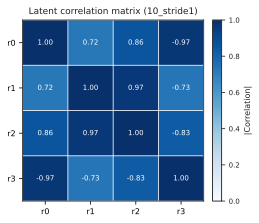

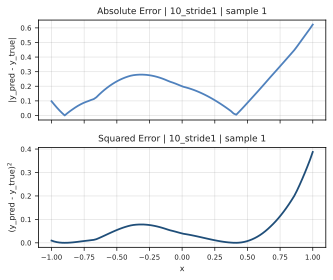

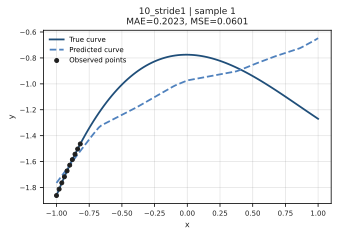

In [ ]:
corr_df = analyse_latent_correlation(net4, test_contexts, "10_stride1", device)

plot_one_test_errors(net4, x_test, y_test, test_contexts, "10_stride1", 1, device)
plot_one_test_prediction(net4, x_test, y_test, test_contexts, "10_stride1", 1, device)


#### Qualitative examples for **model8**

These final examples show the behaviour of the largest latent space and support the final discussion about accuracy, latent usage, and disentangling.

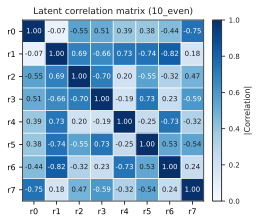

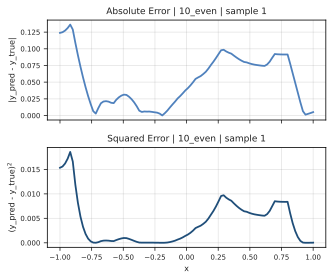

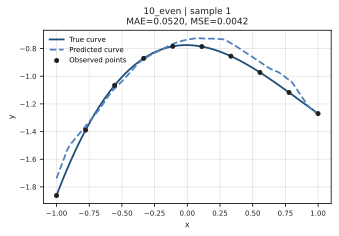

In [ ]:
corr_df = analyse_latent_correlation(net8, test_contexts, "10_even", device)

plot_one_test_errors(net8, x_test, y_test, test_contexts, "10_even", 1, device)
plot_one_test_prediction(net8, x_test, y_test, test_contexts, "10_even", 1, device)



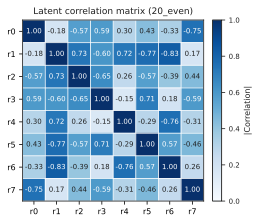

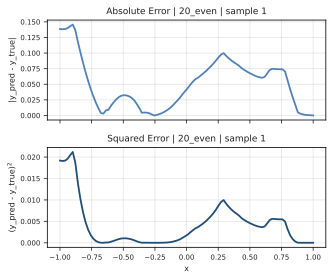

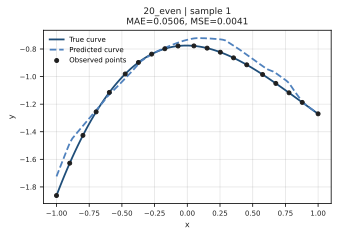

In [ ]:
corr_df = analyse_latent_correlation(net8, test_contexts, "20_even", device)
plot_one_test_errors(net8, x_test, y_test, test_contexts, "20_even", 1, device)
plot_one_test_prediction(net8, x_test, y_test, test_contexts, "20_even", 1, device)



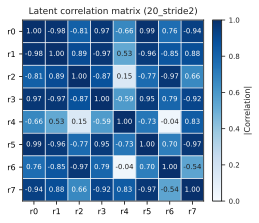

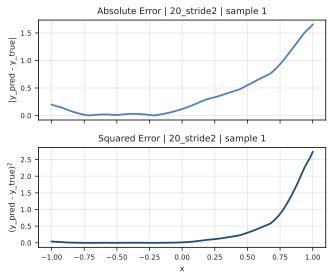

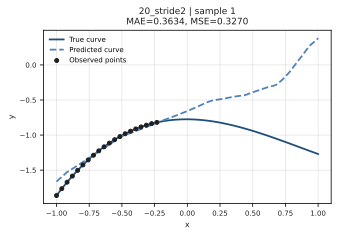

In [ ]:
corr_df = analyse_latent_correlation(net8, test_contexts, "20_stride2", device)

plot_one_test_errors(net8, x_test, y_test, test_contexts, "20_stride2", 1, device)
plot_one_test_prediction(net8, x_test, y_test, test_contexts, "20_stride2", 1, device)



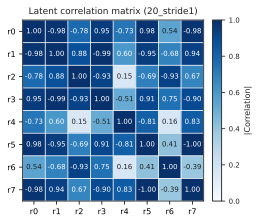

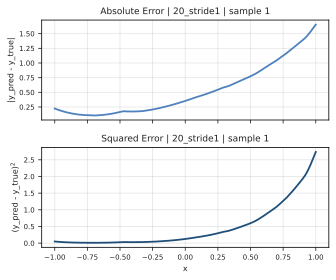

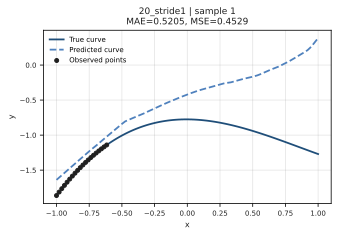

In [ ]:
corr_df = analyse_latent_correlation(net8, test_contexts, "20_stride1", device)

plot_one_test_errors(net8, x_test, y_test, test_contexts, "20_stride1", 1, device)
plot_one_test_prediction(net8, x_test, y_test, test_contexts, "20_stride1", 1, device)


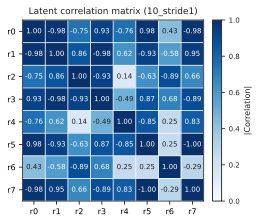

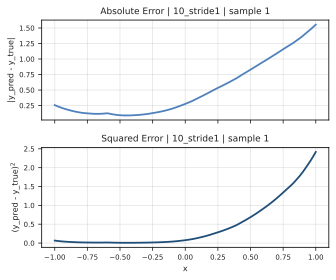

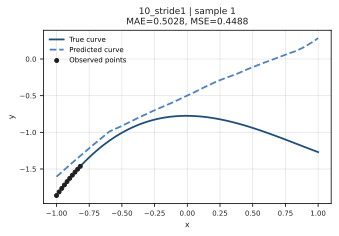

In [ ]:
corr_df = analyse_latent_correlation(net8, test_contexts, "10_stride1", device)

plot_one_test_errors(net8, x_test, y_test, test_contexts, "10_stride1", 1, device)
plot_one_test_prediction(net8, x_test, y_test, test_contexts, "10_stride1", 1, device)
